# Reinforcement Learning — Smart Charging for an Electric Taxi

An electric taxi arrives at the garage every day at **14:00** and departs again at **16:00**.
During this two-hour window, a charging agent decides **every 15 minutes** (8 intervals) what
charging power to use. The goal is to **minimize charging costs** while also **ensuring
that there is enough energy for the workday**.

**3-Way Comparison**: **DQN** vs. **Greedy Heuristic** vs. **price-aware DQN**.

All strategies must cope with a demand that is revealed only at departure. The price-aware DQN
additionally observes the **day-ahead prices** — the market's expectation, published the day
before. The price actually billed, however, is the market price at delivery, which only becomes
known over the course of the charging window itself — none of the strategies observes it.

**Objectives**
- Minimize charging costs
- Ensure that the battery contains enough energy for the workday
- Avoid running out of battery, which results in a high penalty fee

### 1. Imports and Setup

We use `gymnasium` for the environment interface and `stable_baselines3` for DQN training.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
torch.set_num_threads(1)

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

RNG_SEED = 42
np.random.seed(RNG_SEED)

os.makedirs('./logs/best_model_A', exist_ok=True)
os.makedirs('./logs/best_model_B', exist_ok=True)
print('Setup complete. PyTorch threads:', torch.get_num_threads())

Setup complete. PyTorch threads: 1


---
## 2. Environment setup

We model one charging day as one episode. Two environment variants share the same physics
(battery, charging window, hidden demand) and differ only in the tariff used to compute the
charging cost:

- **Stylized cost model** — cost per step $\alpha_t \cdot (p \cdot \Delta t)$: a fixed
  tariff $\alpha_t$ (€/kWh) times the energy actually charged, with $\alpha_t$ rising only
  gently over the window. Grid costs are disregarded — at our scale (a single vehicle at
  ≤ 22 kW) they are negligible, so charging at high power carries no extra cost per kWh.
- **EPEX cost model** — cost per step $\pi_t \cdot (p \cdot \Delta t)$: the same
  energy-proportional form, but with the price $\pi_t$ taken from real EPEX day-ahead data,
  so the tariff varies from day to day and within the window.

### 2.1 Assumptions

| Quantity | Value | Meaning |
|-------|------|-----------|
| Battery capacity $C$ | {40, 60, 77} kWh | uniform per episode — compact, mid-size and large vehicle classes |
| Initial SOC | $\mathcal{U}(20\%,\,60\%)$ of $C$ | varies daily with shift length and route profile |
| Charging window | 8 × 15 min | 14:00 – 16:00 |
| Charging powers | {0, 5, 11, 22} kW | zero / low / medium / high |
| Energy demand $d$ | $\mathcal{N}(30, 5^2)$ kWh, clipped at $C$ | trip demand depends on the route, not on vehicle size — **revealed only at departure** |
| Penalty | 100 €/kWh shortage | very high penalty for insufficient energy |

**On the choice of capacity levels:** 40 kWh corresponds to compact EVs (e.g., older Nissan
Leaf / BMW i3), 60 kWh to the mid-size class (e.g., VW ID.3, Tesla Model 3 SR) and 77 kWh to
larger vehicles (e.g., VW ID.4, Tesla Model 3 LR). A fleet operator typically owns a mix of
these classes.

**On the variability of the initial SOC:** In reality, the state of charge at the end of a
shift depends strongly on the day's driving profile. A taxi that served many short city trips
returns with far more residual charge than one returning from a multi-hour suburban or airport
run. A fixed 40% assumption would ignore this daily variability and train the agent on too
narrow an initial condition. The uniform distribution $\mathcal{U}(20\%, 60\%)$ covers the
realistic range:
- **20 %** corresponds to a nearly empty battery after a long, distance-heavy shift.
- **60 %** corresponds to a taxi after an easy day of many short trips.

Since the initial SOC is directly visible in the state vector, the agent can assess charging
urgency from the start and adapt its strategy accordingly.

**Consequence for difficulty:** Capacity and initial SOC are drawn independently — this creates
a wide range of episode types. A 40-kWh vehicle at 20% initial SOC (8 kWh) with average demand
(30 kWh) has to charge 22 kWh in two hours — tight, but just feasible at full power
(22 kW × 2 h = 44 kWh available). A 77-kWh vehicle at 60% initial SOC (46 kWh), by contrast,
barely needs to charge and can afford to wait for cheap time steps. This variance is
intentional: the agent must learn a strategy that charges correctly under time pressure and
optimizes cost when it has a comfortable buffer.

### 2.2 Markov Decision Process

- **State** $s_t = [\text{SOC}_t,\; t,\; C]$ — state of charge, time step (0–8), vehicle capacity; the realized demand $d$ is **not observable** (next section)
- **Action** $a \in \{0,5,11,22\}$ kW
- **Transition** $\text{SOC}_{t+1} = \min(C,\; \text{SOC}_t + a\cdot 0.25)$
- **Reward** negative charging cost per step; at the end an additional penalty for any shortage
- **Terminal** after 8 decisions

This is the state for the price-unaware strategies; the EPEX variant extends it with day-ahead
price information (section 2.6) — everything else stays identical.

**How these assumptions evolved.** A first modelling pass assumed a single fixed battery
capacity: with a mean daily demand of $\mu=30$ kWh ($\sigma=5$ kWh), a safety reserve of
10–15 kWh was added and rounded up to **50 kWh**, with a fixed initial charge of **20 kWh** on
arrival. With 22 kW × 2 h = 44 kWh the battery could in theory have been charged by 44 kWh, but
in fact only by 50 − 20 = 30 kWh due to the capacity limit. That fixed assumption covered a
single vehicle on an average day; it is replaced here by the three capacity classes and the
variable initial-SOC range, representing a whole fleet and day-to-day variation.

### 2.3 The demand is not observable — the stochastic core of the problem

The energy demand is generated only at the moment the driver wants to leave — during charging
the agent knows only the **distribution** $\mathcal{N}(30, 5^2)$, not the realization $d$. The
demand is therefore deliberately **not** part of the state: the environment draws $d$ in
`reset()` seed-bound (so that DQN, greedy and optimum can be compared on identical episodes),
but reveals it only in the final step through the shortage penalty. The agent must therefore
**hedge** against demand uncertainty — e.g., charge to $\mu + 2\sigma$ — trading charging cost
against penalty risk. If $d$ were part of the state, the problem would be nearly deterministic
and even a simple fill-up rule trivially optimal.

### 2.4 Environment implementation — stylized cost model

In [2]:
class TaxiChargingEnvSimple(gym.Env):
    """
    Environment with the stylized, energy-proportional cost function
    alpha_t * (energy actually added), alpha_t in EUR/kWh.

    State : [SOC (kWh), time step (0..8), capacity C (kWh)]
            The energy demand d is deliberately NOT part of the state: it is
            generated only at departure. It is drawn seed-bound in reset() (for
            paired evaluation), but only revealed in the final step.
    Action: index into power_levels = [0, 5, 11, 22] kW
    Reward: -charging cost per step; in the final step additionally -100 per missing kWh
    """
    metadata = {'render_modes': []}

    CAPACITY_OPTIONS     = np.array([40.0, 60.0, 77.0])  # kWh: compact / mid-size / large
    INITIAL_SOC_FRAC_MIN = 0.20   # min SOC at arrival (long, distance-heavy shift)
    INITIAL_SOC_FRAC_MAX = 0.60   # max SOC at arrival (short city shift)

    def __init__(self):
        super().__init__()
        self.max_steps    = 8    # number of charging decisions (2h / 15min = 8 intervals)
        self.interval_h   = 0.25 # one interval = 15 minutes = 0.25 hours
        self.power_levels = [0, 5, 11, 22]  # zero / low / medium / high (kW)
        self.demand_mean  = 30.0
        self.demand_std   = 5.0
        # fixed tariff in EUR/kWh, rising only gently over the window
        # (grid costs are neglected: one vehicle at <= 22 kW is negligible at grid scale)
        self.alpha_t = np.array(
            [0.140, 0.143, 0.146, 0.149,
             0.151, 0.154, 0.157, 0.160], dtype=np.float64)
        self.shortage_penalty = 100.0  # penalty per missing kWh at the end of the episode

        cap_max = float(self.CAPACITY_OPTIONS.max())
        cap_min = float(self.CAPACITY_OPTIONS.min())
        self.action_space = spaces.Discrete(len(self.power_levels))
        self.observation_space = spaces.Box(
            low =np.array([0.0,     0.0, cap_min], dtype=np.float32),
            high=np.array([cap_max, 8.0, cap_max], dtype=np.float32),
            dtype=np.float32)

        # placeholders — set in reset()
        self.capacity    = float(self.CAPACITY_OPTIONS.mean())
        self.initial_soc = 0.40 * self.capacity
        self.soc         = self.initial_soc
        self.current_step = 0
        self.demand      = self.demand_mean
        self.total_cost  = 0.0

    def _get_obs(self):
        return np.array([self.soc, float(self.current_step), self.capacity],
                        dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.total_cost   = 0.0
        idx = int(self.np_random.integers(0, len(self.CAPACITY_OPTIONS)))
        self.capacity    = float(self.CAPACITY_OPTIONS[idx])
        soc_frac         = float(self.np_random.uniform(self.INITIAL_SOC_FRAC_MIN,
                                                         self.INITIAL_SOC_FRAC_MAX))
        self.initial_soc = soc_frac * self.capacity
        self.soc         = self.initial_soc
        self.demand = float(np.clip(
            self.np_random.normal(self.demand_mean, self.demand_std), 0.0, self.capacity))
        return self._get_obs(), {}

    def step(self, action):
        power = self.power_levels[int(action)]
        previous_soc = self.soc
        self.soc = min(self.capacity, self.soc + power * self.interval_h)
        actual_energy_added = self.soc - previous_soc

        alpha = self.alpha_t[self.current_step]
        charging_cost = alpha * actual_energy_added
        self.total_cost += charging_cost
        reward = -charging_cost

        self.current_step += 1
        terminated = False
        info = {'power': power, 'energy_added': actual_energy_added,
                'charging_cost': charging_cost, 'total_cost': self.total_cost,
                'soc': self.soc, 'demand': self.demand, 'capacity': self.capacity}

        if self.current_step >= self.max_steps:
            shortage = max(0.0, self.demand - self.soc)
            reward -= self.shortage_penalty * shortage
            info.update({'shortage': shortage, 'success': shortage == 0.0, 'final_soc': self.soc})
            terminated = True
        return self._get_obs(), float(reward), terminated, False, info


**Cost function.** Charging cost is proportional to the energy actually added:
$$\text{cost}(t, p) = \alpha_t \cdot (p \cdot \Delta t),$$
with a fixed tariff $\alpha_t$ that rises gently from 0.140 to 0.160 €/kWh over the charging
window. Grid costs are disregarded: at the scale of a single vehicle charging at ≤ 22 kW they
are negligible, so high charging power carries no cost premium per kWh.

**Sanity check of the cost scaling.** We verify that charging is cheaper than the penalty.

In [4]:
env_tmp = TaxiChargingEnvSimple()
worst = sum(a * 22 * env_tmp.interval_h for a in env_tmp.alpha_t)
print(f'Maximum charging cost (8 x 22 kW = 44 kWh): {worst:6.2f} EUR')
print(f'Penalty per missing kWh                   : {env_tmp.shortage_penalty:6.0f} EUR')
print(f'Ratio penalty / max cost                  : {env_tmp.shortage_penalty / worst:5.1f}x')
print('=> Charging enough always pays off compared to the penalty risk.')

Maximum charging cost (8 x 22 kW = 44 kWh):   6.60 EUR
Penalty per missing kWh                   :    100 EUR
Ratio penalty / max cost                  :  15.2x
=> Charging enough always pays off compared to the penalty risk.


### 2.5 Real EPEX day-ahead prices — data source and preparation

For the second cost model, real electricity prices replace the fixed stylized tariff: charging
still costs price × energy actually charged, but **every episode draws a different real day**,
so the price level and shape vary from episode to episode.

**Source:** Fraunhofer ISE *Energy-Charts* API (data from ENTSO-E / EPEX SPOT, license CC BY 4.0).
**Period:** Q1 2025 (January–March), bidding zone **DE-LU**, hourly day-ahead prices.
**Window:** For each day, the hours 14:00–15:00 and 15:00–16:00 are used. The hourly prices are
**linearly interpolated to four quarter-hour steps** — i.e. the price rises or falls evenly
within each hour toward the next hourly value instead of staying constant for all four steps.
The result is stored as `epex_windows_q1_2025.npy`.

**Day-ahead price vs. procurement price.** In our setting the day-ahead price plays the role of
a **forecast**: it is what the market expects and it is published the day before, so a charging
agent may legitimately know it. The electricity itself, however, is not bought on the day-ahead
auction — the provider bills the current market price at delivery time. We model this
procurement price as the day-ahead price plus a zero-mean deviation
$\varepsilon_t \sim \mathcal{N}(0,\, 0.015^2)$ €/kWh (≈ 15 €/MWh, the typical order of
magnitude of short-term deviations from the day-ahead expectation). The agent never observes
$\varepsilon_t$ — it plans on the expectation and pays the realization.

In [5]:
import requests, pandas as pd, numpy as np

def fetch_epex_dayahead(start="2025-01-01", end="2025-03-31", bzn="DE-LU"):
    url = f"https://api.energy-charts.info/price?bzn={bzn}&start={start}&end={end}"
    data = requests.get(url, timeout=30).json()
    ts    = pd.to_datetime(data["unix_seconds"], unit="s", utc=True).tz_convert("Europe/Berlin")
    price = np.array(data["price"], dtype=float) / 1000.0   # EUR/MWh -> EUR/kWh
    s = pd.Series(price, index=ts)
    # per day, take hours 14, 15 and 16 and interpolate linearly to quarter hours
    days = []
    for day, grp in s.groupby(s.index.date):
        h14 = grp[grp.index.hour == 14]
        h15 = grp[grp.index.hour == 15]
        h16 = grp[grp.index.hour == 16]
        if len(h14) and len(h15) and len(h16):
            p14, p15, p16 = h14.iloc[0], h15.iloc[0], h16.iloc[0]
            # np.linspace(a, b, 5)[:-1] gives [a, a+d, a+2d, a+3d] with d=(b-a)/4
            window = (list(np.linspace(p14, p15, 5)[:-1]) +
                      list(np.linspace(p15, p16, 5)[:-1]))
            days.append(window)
    return np.array(days)                                  # shape (n_days, 8)

# reproducibility: prefer the local price cache, API only as fallback
EPEX_CACHE = "epex_windows_q1_2025.npy"
if os.path.exists(EPEX_CACHE):
    EPEX_WINDOWS = np.load(EPEX_CACHE)
    print(f'Price windows loaded from local cache: {EPEX_CACHE}')
else:
    EPEX_WINDOWS = fetch_epex_dayahead()
    np.save(EPEX_CACHE, EPEX_WINDOWS)
    print('Price windows freshly fetched from the Energy-Charts API and cached.')
print(f'Price windows loaded: {EPEX_WINDOWS.shape} (days, steps)')
print(f'Price range (EUR/kWh): min={EPEX_WINDOWS.min():.3f}, '
      f'median={np.median(EPEX_WINDOWS):.3f}, max={EPEX_WINDOWS.max():.3f}')

Price windows loaded from local cache: epex_windows_q1_2025.npy
Price windows loaded: (90, 8) (days, steps)
Price range (EUR/kWh): min=-0.026, median=0.110, max=0.371


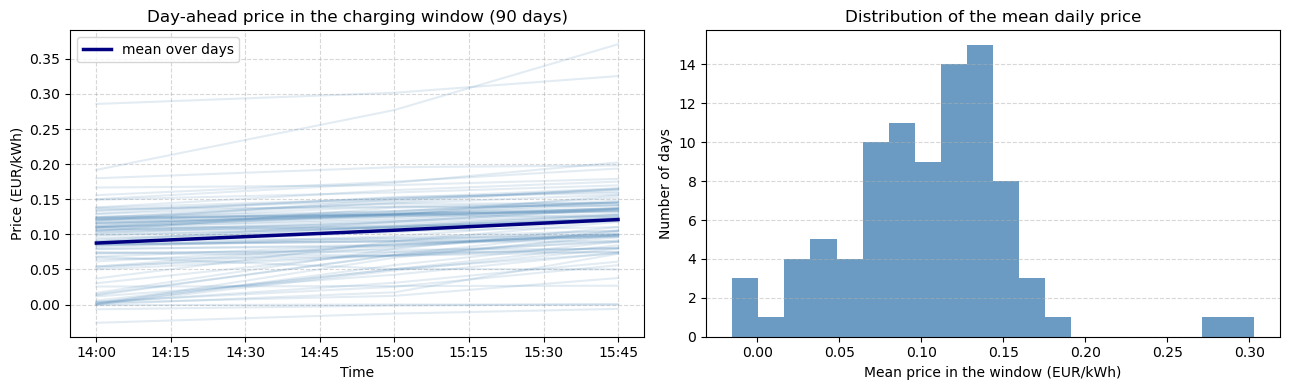

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
n_days = len(EPEX_WINDOWS)
steps = np.arange(8)
time_labels = ['14:00', '14:15', '14:30', '14:45', '15:00', '15:15', '15:30', '15:45']

for w in EPEX_WINDOWS:
    ax[0].plot(steps, w, color='steelblue', alpha=0.15)
ax[0].plot(steps, EPEX_WINDOWS.mean(axis=0), color='navy', lw=2.5, label='mean over days')
ax[0].set_title(f'Day-ahead price in the charging window ({n_days} days)')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Price (EUR/kWh)')
ax[0].set_xticks(steps)
ax[0].set_xticklabels(time_labels)
ax[0].legend(); ax[0].grid(True, ls='--', alpha=0.5)

ax[1].hist(EPEX_WINDOWS.mean(axis=1), bins=20, color='steelblue', alpha=0.8)
ax[1].set_title('Distribution of the mean daily price')
ax[1].set_xlabel('Mean price in the window (EUR/kWh)')
ax[1].set_ylabel('Number of days')
ax[1].grid(True, axis='y', ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

### 2.6 Environment implementation — EPEX cost model

Two changes compared to the stylized environment:

1. **Billing at realized prices.** Each step costs realized procurement price × energy actually
   charged, with the procurement price $\pi_t = \pi_t^{DA} + \varepsilon_t$ (day-ahead price
   plus the unobserved deviation from section 2.5).
2. **The day-ahead prices are observable.** The state is extended to
   $s_t = [\text{SOC}_t,\; t,\; C,\; \pi_t^{DA},\; \bar\pi_{>t}^{DA}]$ — the current
   day-ahead price and the mean remaining day-ahead price, so the agent can weigh "cheap now
   vs. cheaper later" for the *individual* day. It sees the market's expectation, never the
   price it actually pays.

The realized demand $d$ stays hidden until departure, as before.

In [7]:
class TaxiChargingEnvEPEX(gym.Env):
    """
    Environment with real EPEX day-ahead prices and a heterogeneous fleet.

    State : [SOC (kWh), time step (0..8), capacity C (kWh),
             day-ahead price now, mean remaining day-ahead price]
            The agent sees the DAY-AHEAD prices (the market's expectation,
            published in advance). Billing uses the realized procurement price
            = day-ahead + eps_t, eps_t ~ N(0, INTRADAY_STD^2), which the agent
            never observes. The demand d also stays hidden until departure.
    Action: index into power_levels = [0, 5, 11, 22] kW
    Reward: -realized price * energy charged per step; at the end -100 per missing kWh
    """
    metadata = {'render_modes': []}

    CAPACITY_OPTIONS     = np.array([40.0, 60.0, 77.0])
    INITIAL_SOC_FRAC_MIN = 0.20   # min SOC at arrival (long, distance-heavy shift)
    INITIAL_SOC_FRAC_MAX = 0.60   # max SOC at arrival (short city shift)
    INTRADAY_STD         = 0.015  # EUR/kWh (~15 EUR/MWh): deviation of the procurement
                                  # price from the day-ahead expectation

    def __init__(self, price_windows):
        super().__init__()
        self.price_windows = np.asarray(price_windows, dtype=np.float64)
        self.max_steps    = 8
        self.interval_h   = 0.25
        self.power_levels = [0, 5, 11, 22]
        self.demand_mean  = 30.0
        self.demand_std   = 5.0
        self.shortage_penalty = 100.0

        cap_max = float(self.CAPACITY_OPTIONS.max())
        cap_min = float(self.CAPACITY_OPTIONS.min())
        plow    = float(self.price_windows.min()) - 0.1   # day-ahead prices can be negative
        phigh   = float(self.price_windows.max()) * 1.5
        self.action_space = spaces.Discrete(len(self.power_levels))
        self.observation_space = spaces.Box(
            low =np.array([0.0,     0.0, cap_min, plow,  plow ], dtype=np.float32),
            high=np.array([cap_max, 8.0, cap_max, phigh, phigh], dtype=np.float32),
            dtype=np.float32)

        # placeholders — set in reset()
        self.capacity    = float(self.CAPACITY_OPTIONS.mean())
        self.initial_soc = 0.40 * self.capacity
        self.soc         = self.initial_soc
        self.current_step = 0
        self.demand      = self.demand_mean
        self.prices_da   = self.price_windows[0]
        self.prices_real = self.prices_da.copy()
        self.total_cost  = 0.0

    def _mean_remaining_da(self):
        if self.current_step >= self.max_steps:
            return 0.0
        return float(self.prices_da[self.current_step:].mean())

    def _get_obs(self):
        da_now = float(self.prices_da[self.current_step]) if self.current_step < self.max_steps else 0.0
        return np.array([self.soc, float(self.current_step), self.capacity,
                         da_now, self._mean_remaining_da()], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.total_cost   = 0.0
        idx = int(self.np_random.integers(0, len(self.CAPACITY_OPTIONS)))
        self.capacity    = float(self.CAPACITY_OPTIONS[idx])
        soc_frac         = float(self.np_random.uniform(self.INITIAL_SOC_FRAC_MIN,
                                                         self.INITIAL_SOC_FRAC_MAX))
        self.initial_soc = soc_frac * self.capacity
        self.soc         = self.initial_soc
        self.demand = float(np.clip(
            self.np_random.normal(self.demand_mean, self.demand_std), 0.0, self.capacity))
        price_idx        = int(self.np_random.integers(0, len(self.price_windows)))
        self.prices_da   = self.price_windows[price_idx]
        eps              = self.np_random.normal(0.0, self.INTRADAY_STD, size=self.max_steps)
        self.prices_real = self.prices_da + eps
        return self._get_obs(), {}

    def step(self, action):
        power = self.power_levels[int(action)]
        previous_soc = self.soc
        self.soc = min(self.capacity, self.soc + power * self.interval_h)
        actual_energy_added = self.soc - previous_soc

        price = float(self.prices_real[self.current_step])
        charging_cost = price * actual_energy_added
        self.total_cost += charging_cost
        reward = -charging_cost

        self.current_step += 1
        terminated = False
        info = {'power': power, 'energy_added': actual_energy_added,
                'charging_cost': charging_cost, 'total_cost': self.total_cost,
                'soc': self.soc, 'demand': self.demand,
                'price_da': float(self.prices_da[self.current_step - 1]),
                'price_paid': price, 'capacity': self.capacity}

        if self.current_step >= self.max_steps:
            shortage = max(0.0, self.demand - self.soc)
            reward -= self.shortage_penalty * shortage
            info.update({'shortage': shortage, 'success': shortage == 0.0, 'final_soc': self.soc})
            terminated = True
        return self._get_obs(), float(reward), terminated, False, info


In [8]:
check_env(TaxiChargingEnvEPEX(EPEX_WINDOWS))
print('EPEX environment check passed.')

EPEX environment check passed.


---
## 3. Optimum computation — exact optimum via brute force

The action space is tiny: 4 actions over 8 steps = $4^8 = 65{,}536$ possible charging plans. For
a given episode (fixed demand, fixed prices) we can therefore **try every plan** and find the
cost-optimal one that covers the demand. This yields a true upper bound on the achievable
reward — relative to it we measure how good the three strategies *really* are, instead of only
comparing them with each other.

**Important:** the brute-force optimum is an **oracle** — it knows the realized demand $d$ (and
in the EPEX setting the prices that will actually be billed, not just the day-ahead forecast)
in advance. No feasible policy can reach this upper
bound; the gap to the oracle is precisely the price of uncertainty.

In [9]:
from itertools import product

def optimal_episode_reward(env_proto, demand, price_vector=None):
    """
    Determines by brute force the maximum achievable episode reward for a given
    demand (and optionally a price vector for the EPEX setting).
    env_proto only supplies the parameters (capacity, power_levels, ...).
    """
    cap   = env_proto.capacity
    soc0  = env_proto.initial_soc
    ih    = env_proto.interval_h
    P     = env_proto.power_levels
    pen   = env_proto.shortage_penalty
    n     = env_proto.max_steps
    tariff = env_proto.alpha_t if price_vector is None else price_vector

    best = -np.inf
    for plan in product(range(len(P)), repeat=n):
        soc = soc0
        cost = 0.0
        for t, a in enumerate(plan):
            p = P[a]
            new_soc = min(cap, soc + p * ih)
            # both cost models: tariff (EUR/kWh) * energy actually charged
            cost += tariff[t] * (new_soc - soc)
            soc = new_soc
        shortage = max(0.0, demand - soc)
        reward = -cost - pen * shortage
        if reward > best:
            best = reward
    return best


---
## 4. Model 1 — Greedy heuristic

The heuristic is price-independent and — like all strategies compared here — does not know the realized
demand: it charges toward a safety target $\tau = \min(C,\, \mu + 2\sigma) = \min(C,\, 40\,\text{kWh})$
(≈ 97.7% service level under $\mathcal{N}(30, 5^2)$), spreads the missing energy evenly over
the remaining time steps, and selects the smallest power level that achieves this. This
intuitive fill-up rule serves as the reference in **both** cost settings. It is exactly where it
is decided whether RL adds value: as long as every kWh costs about the same, "fill up evenly" is
nearly optimal — once prices systematically vary over the window, it no longer is. Because the
rule only reads generic environment fields (SOC, time step, capacity), the same function runs
unchanged in both environments.

In [10]:
def greedy_episode(env, seed=None):
    """Greedy heuristic WITHOUT knowledge of the realized demand: since d is revealed
    only at departure, the rule charges toward a safety target tau = min(C, mu + 2*sigma)
    (~97.7% service level under N(mu, sigma^2)) and spreads the missing energy evenly
    over the remaining steps (smallest sufficient power level). Runs unchanged in the
    stylized and in the EPEX environment."""
    obs, _ = env.reset(seed=seed)
    done = False
    ep_reward = 0.0
    ep_cost = 0.0
    soc_traj = [float(obs[0])]
    target = min(float(obs[2]), env.demand_mean + 2 * env.demand_std)  # obs[2] = capacity C
    info = {}
    while not done:
        soc, step = float(obs[0]), int(obs[1])
        remaining = env.max_steps - step
        if soc >= target:
            action = 0
        else:
            needed_kw = (target - soc) / (remaining * env.interval_h)
            action = len(env.power_levels) - 1
            for i, p in enumerate(env.power_levels):
                if p >= needed_kw:
                    action = i
                    break
        obs, reward, done, _, info = env.step(int(action))
        ep_reward += reward
        ep_cost += info.get('charging_cost', 0.0)
        soc_traj.append(float(obs[0]))
    return ep_reward, ep_cost, bool(info.get('success', False)), soc_traj


---
## 5. Model 2 — DQN without EPEX day-ahead data

This first agent is trained entirely in the **stylized cost environment** — it never sees any
EPEX data.

**Why deep RL instead of tabular Q-learning?** The state space is **continuous** (SOC
$\in [0, C]$, capacity). Tabular Q-learning would require discretizing all of these dimensions
and would grow combinatorially with every state extension; a DQN generalizes across continuous
states, and the same architecture transfers unchanged to the EPEX setting.

An `EvalCallback` tracks the learning curve. At 8 steps/episode, 200,000 time steps correspond
to about 25,000 simulated days.

In [11]:
train_env_A = Monitor(TaxiChargingEnvSimple())
eval_env_A  = Monitor(TaxiChargingEnvSimple())

eval_cb_A = EvalCallback(eval_env_A, best_model_save_path='./logs/best_model_A',
                         log_path='./logs/log_A', eval_freq=2_000,
                         n_eval_episodes=200, deterministic=True, render=False, verbose=0)

model_A = DQN('MlpPolicy', train_env_A,
              learning_rate=5e-4, buffer_size=50_000, learning_starts=2_000,
              batch_size=128, gamma=0.99, train_freq=4, target_update_interval=500,
              exploration_fraction=0.2, exploration_final_eps=0.02,
              policy_kwargs=dict(net_arch=[128, 128]), seed=RNG_SEED, verbose=0)

model_A.learn(total_timesteps=200_000, callback=eval_cb_A)
model_A.save('taxi_charging_dqn_simple')
print('Training of the DQN without EPEX data complete.')

Training of the DQN without EPEX data complete.


### 5.1 Paired evaluation in the stylized cost setting

DQN and greedy are evaluated on **identical** episodes (same seeds → same capacity, initial SOC
and demand), so rewards are compared *paired per episode*. For a subset of 100 episodes, the
exact brute-force optimum is computed in addition. The evaluation routine below is generic and
is reused later for the comparison on real prices.

In [12]:
def evaluate_policy(model, env, seeds, obs_dims=None):
    """Runs a trained model deterministically on the given seeds (paired evaluation).
    obs_dims: if set, the model only receives the first obs_dims state components —
    this lets the 3-dim stylized-cost agent act in the 5-dim EPEX environment."""
    rewards, costs, successes, trajs = [], [], [], []
    action_counts = np.zeros(len(env.power_levels))
    for sd in seeds:
        obs, _ = env.reset(seed=int(sd))
        done = False
        ep_r, ep_c = 0.0, 0.0
        traj = [float(obs[0])]
        info = {}
        while not done:
            pobs = obs if obs_dims is None else obs[:obs_dims]
            action, _ = model.predict(pobs, deterministic=True)
            action = int(action)
            action_counts[action] += 1
            obs, reward, done, _, info = env.step(action)
            ep_r += reward
            ep_c += info.get('charging_cost', 0.0)
            traj.append(float(obs[0]))
        rewards.append(ep_r)
        costs.append(ep_c)
        successes.append(bool(info.get('success', False)))
        trajs.append(traj)
    return (np.array(rewards), np.array(costs), np.array(successes),
            np.array(trajs), action_counts)

N_EVAL = 1000
eval_seeds = np.arange(10_000, 10_000 + N_EVAL)

# DQN (trained without EPEX data) in its training environment
dqn_env_A = TaxiChargingEnvSimple()
dqnA_r, dqnA_c, dqnA_s, dqnA_traj, dqnA_actions = evaluate_policy(model_A, dqn_env_A, eval_seeds)

# greedy on identical seeds
grd_env_A = TaxiChargingEnvSimple()
grd_results_A = [greedy_episode(grd_env_A, seed=int(sd)) for sd in eval_seeds]
grdA_r, grdA_c, grdA_s, grdA_traj = [np.array(x) for x in zip(*grd_results_A)]

# exact optimum on a subset (brute force is expensive)
opt_proto = TaxiChargingEnvSimple()
opt_seeds = eval_seeds[:100]
optA = []
for sd in opt_seeds:
    opt_proto.reset(seed=int(sd))
    optA.append(optimal_episode_reward(opt_proto, demand=float(opt_proto.demand)))
optA = np.array(optA)

n_opt = len(optA)
print('=== Stylized cost setting: results (1000 paired episodes) ===')
print(f'DQN     | success {dqnA_s.mean()*100:5.1f}% | reward {dqnA_r.mean():7.3f} +/- {dqnA_r.std():.3f}')
print(f'Greedy  | success {grdA_s.mean()*100:5.1f}% | reward {grdA_r.mean():7.3f} +/- {grdA_r.std():.3f}')
print(f'--- comparison on the same {n_opt} episodes (brute-force subset) ---')
print(f'Greedy  (n={n_opt})                  | reward {grdA_r[:n_opt].mean():7.3f}')
print(f'Optimum (n={n_opt}, brute-force oracle) | reward {optA.mean():7.3f}')
diff = dqnA_r - grdA_r
print(f'\nPaired difference (DQN - greedy): {diff.mean():+.4f}  '
      f'95%-CI [{diff.mean()-1.96*diff.std()/np.sqrt(N_EVAL):+.4f}, '
      f'{diff.mean()+1.96*diff.std()/np.sqrt(N_EVAL):+.4f}]')

=== Stylized cost setting: results (1000 paired episodes) ===
DQN     | success  70.1% | reward -105.426 +/- 220.272
Greedy  | success  98.9% | reward  -4.548 +/- 23.925
--- comparison on the same 100 episodes (brute-force subset) ---
Greedy  (n=100)                  | reward  -5.599
Optimum (n=100, brute-force oracle) | reward  -1.449

Paired difference (DQN - greedy): -100.8779  95%-CI [-114.1071, -87.6487]


### 5.2 Example episode

The trace below shows the DQN agent's charging path for a single episode: step by step the
time, chosen charging power, energy actually added, cost incurred, and resulting state of
charge.

In [13]:
trace_env = TaxiChargingEnvSimple()
obs, _ = trace_env.reset(seed=0)
trace, done = [], False

while not done:
    old_soc  = float(obs[0])
    old_step = int(obs[1])
    action, _ = model_A.predict(obs, deterministic=True)
    obs, reward, done, _, info = trace_env.step(int(action))
    trace.append({
        'Step':                 old_step,
        'Time':                 f'{14 + old_step*0.25:05.2f}',
        'Capacity (kWh)':       int(info['capacity']),
        'SOC before (kWh)':     round(old_soc, 2),
        'Action (kW)':          int(info['power']),
        'Energy added (kWh)':   round(float(info['energy_added']), 3),
        'Charging cost':        round(float(info['charging_cost']), 8),
        'SOC after (kWh)':      round(float(info['soc']), 2),
        'Reward':                round(float(reward), 4),
        'Demand (kWh)':         round(float(info['demand']), 2),
        'Shortage (kWh)':       round(float(info.get('shortage', 0.0)), 2),
        'Success':              bool(info['success']) if done else False,
    })

df_trace_A = pd.DataFrame(trace)
df_trace_A

,Step,Time,Capacity (kWh),SOC before (kWh),Action (kW),Energy added (kWh),Charging cost,SOC after (kWh),Reward,Demand (kWh),Shortage (kWh),Success
0,0,14.00,77,23.71,0,0.00,0.00000,23.71,-0.0000,33.2,0.0,False
1,1,14.25,77,23.71,0,0.00,0.00000,23.71,-0.0000,33.2,0.0,False
2,2,14.50,77,23.71,5,1.25,0.18250,24.96,-0.1825,33.2,0.0,False
3,3,14.75,77,24.96,5,1.25,0.18625,26.21,-0.1862,33.2,0.0,False
4,4,15.00,77,26.21,11,2.75,0.41525,28.96,-0.4153,33.2,0.0,False
5,5,15.25,77,28.96,11,2.75,0.42350,31.71,-0.4235,33.2,0.0,False
6,6,15.50,77,31.71,5,1.25,0.19625,32.96,-0.1962,33.2,0.0,False
7,7,15.75,77,32.96,5,1.25,0.20000,34.21,-0.2000,33.2,0.0,True


**Interim conclusion.** With an almost flat tariff (0.140 → 0.160 €/kWh) the only difficulty
is **demand uncertainty**, and hedging it is cheap: one extra kWh of buffer costs ≈ 0.15 €,
while one missing kWh costs 100 €. The service-level heuristic ($\tau = \mu + 2\sigma$)
prices this trade correctly by construction and reaches **98.9%** success at a cost close to
the oracle optimum. The DQN does not: it learns to charge only up to roughly the **mean**
demand and then stops, reaching **70.1%** success —
the rare but extreme shortage penalty drags its mean reward far below greedy (paired reward
difference ≈ **−101**). Rare tail events are exactly what a value-based learner estimates
poorly from sampled experience, while the explicit service-level rule gets the tail right for
free. The finding: *without systematic price variation there is nothing for RL to gain over a
good service-level rule — there is only tail risk to mis-price.* The interesting question is
what happens once real, varying prices enter the reward.

---
## 6. Model 3 — Price-aware DQN with EPEX day-ahead data

The third agent is trained with the **same hyperparameters** — fair for the comparison. Two
things distinguish it from Model 2: it is trained on real EPEX prices, and it **observes the
day-ahead prices** in its state — the market's expectation for each quarter-hour, known in
advance. It can therefore react to the *individual* day: charge when the day is cheap, wait
when it is expensive. What it cannot see is the price it will actually pay (day-ahead plus the
unobserved deviation) — and, as always, the realized demand.

In [14]:
train_env_B = Monitor(TaxiChargingEnvEPEX(EPEX_WINDOWS))
eval_env_B  = Monitor(TaxiChargingEnvEPEX(EPEX_WINDOWS))

eval_cb_B = EvalCallback(eval_env_B, best_model_save_path='./logs/best_model_B',
                         log_path='./logs/log_B', eval_freq=2_000,
                         n_eval_episodes=200, deterministic=True, render=False, verbose=0)

model_B = DQN('MlpPolicy', train_env_B,
              learning_rate=5e-4, buffer_size=50_000, learning_starts=2_000,
              batch_size=128, gamma=0.99, train_freq=4, target_update_interval=500,
              exploration_fraction=0.2, exploration_final_eps=0.02,
              policy_kwargs=dict(net_arch=[128, 128]), seed=RNG_SEED, verbose=0)

model_B.learn(total_timesteps=200_000, callback=eval_cb_B)
model_B.save('taxi_charging_dqn_epex')
print('Training of the DQN with EPEX data complete.')

Training of the DQN with EPEX data complete.


---
## 7. Comparison of the three models against the optimum

On real prices the natural metric is **charging cost in euros**. All three strategies are
evaluated pairwise on identical episodes of the EPEX environment (same seed → same capacity,
initial SOC, demand, the same real day **and** the same procurement-price deviations). The
stylized-cost agent acts in the EPEX environment by receiving only the $[\text{SOC}, t, C]$
part of the state — its policy never used price information anyway. The exact (oracle) optimum,
computed with the true demand and the true realized price vector of each episode, serves as the
yardstick.

For the cost comparisons we restrict to episodes where the compared strategies cover the
demand — otherwise the 100 €/kWh penalty distorts the picture.

In [15]:
# all three strategies on identical EPEX episodes
dqn_env_B = TaxiChargingEnvEPEX(EPEX_WINDOWS)
dqnB_r, dqnB_c, dqnB_s, dqnB_traj, dqnB_actions = evaluate_policy(model_B, dqn_env_B, eval_seeds)

dqn_env_AonB = TaxiChargingEnvEPEX(EPEX_WINDOWS)
dqnAe_r, dqnAe_c, dqnAe_s, dqnAe_traj, dqnAe_actions = evaluate_policy(
    model_A, dqn_env_AonB, eval_seeds, obs_dims=3)

grd_env_B = TaxiChargingEnvEPEX(EPEX_WINDOWS)
grd_results_B = [greedy_episode(grd_env_B, seed=int(sd)) for sd in eval_seeds]
grdB_r, grdB_c, grdB_s, grdB_traj = [np.array(x) for x in zip(*grd_results_B)]

# exact optimum (reward) on a subset: with the true demand and realized price vector
opt_proto_B = TaxiChargingEnvEPEX(EPEX_WINDOWS)
optB = []
for sd in opt_seeds:
    opt_proto_B.reset(seed=int(sd))
    optB.append(optimal_episode_reward(opt_proto_B, demand=float(opt_proto_B.demand),
                                       price_vector=opt_proto_B.prices_real))
optB = np.array(optB)

print('=== Comparison on 1000 paired episodes with real EPEX prices ===')
print(f'Greedy                | success {grdB_s.mean()*100:5.1f}% | reward {grdB_r.mean():8.4f} | '
      f'charging cost {grdB_c.mean():.4f} EUR/day')
print(f'DQN (no EPEX data)    | success {dqnAe_s.mean()*100:5.1f}% | reward {dqnAe_r.mean():8.4f} | '
      f'charging cost {dqnAe_c.mean():.4f} EUR/day')
print(f'DQN (price-aware)     | success {dqnB_s.mean()*100:5.1f}% | reward {dqnB_r.mean():8.4f} | '
      f'charging cost {dqnB_c.mean():.4f} EUR/day')
print(f'Optimum (n={len(optB)}, oracle) | reward {optB.mean():8.4f}')

mask_B = dqnB_s & grdB_s
if mask_B.sum() > 0:
    saving = grdB_c[mask_B].mean() - dqnB_c[mask_B].mean()
    print(f'\nMean cost saving DQN (price-aware) vs. greedy '
          f'(episodes where both succeed, n={mask_B.sum()}): {saving:+.4f} EUR/day '
          f'({saving/grdB_c[mask_B].mean()*100:+.1f}%)')
mask_A = dqnAe_s & grdB_s
if mask_A.sum() > 0:
    saving_A = grdB_c[mask_A].mean() - dqnAe_c[mask_A].mean()
    print(f'Mean cost saving DQN (no EPEX data) vs. greedy '
          f'(episodes where both succeed, n={mask_A.sum()}): {saving_A:+.4f} EUR/day '
          f'({saving_A/grdB_c[mask_A].mean()*100:+.1f}%)')

=== Comparison on 1000 paired episodes with real EPEX prices ===
Greedy                | success  98.9% | reward  -3.7594 | charging cost 1.7042 EUR/day
DQN (no EPEX data)    | success  70.1% | reward -105.0054 | charging cost 1.0219 EUR/day
DQN (price-aware)     | success  75.9% | reward -84.7630 | charging cost 0.9722 EUR/day
Optimum (n=100, oracle) | reward  -0.9744

Mean cost saving DQN (price-aware) vs. greedy (episodes where both succeed, n=759): +0.6623 EUR/day (+43.1%)
Mean cost saving DQN (no EPEX data) vs. greedy (episodes where both succeed, n=701): +0.6414 EUR/day (+40.6%)


In [16]:
summary = pd.DataFrame({
    'Model': ['Greedy heuristic', 'DQN (no EPEX data)', 'DQN (price-aware)',
              'Oracle optimum (n=100)'],
    'Success rate (%)': [grdB_s.mean()*100, dqnAe_s.mean()*100, dqnB_s.mean()*100, 100.0],
    'Mean reward': [grdB_r.mean(), dqnAe_r.mean(), dqnB_r.mean(), optB.mean()],
    'Charging cost (EUR/day)': [grdB_c.mean(), dqnAe_c.mean(), dqnB_c.mean(), -optB.mean()],
})
summary.round(4)

,Model,Success rate (%),Mean reward,Charging cost (EUR/day)
0,Greedy heuristic,98.9,-3.7594,1.7042
1,DQN (no EPEX data),70.1,-105.0054,1.0219
2,DQN (price-aware),75.9,-84.7630,0.9722
3,Oracle optimum (n=100),100.0,-0.9744,0.9744


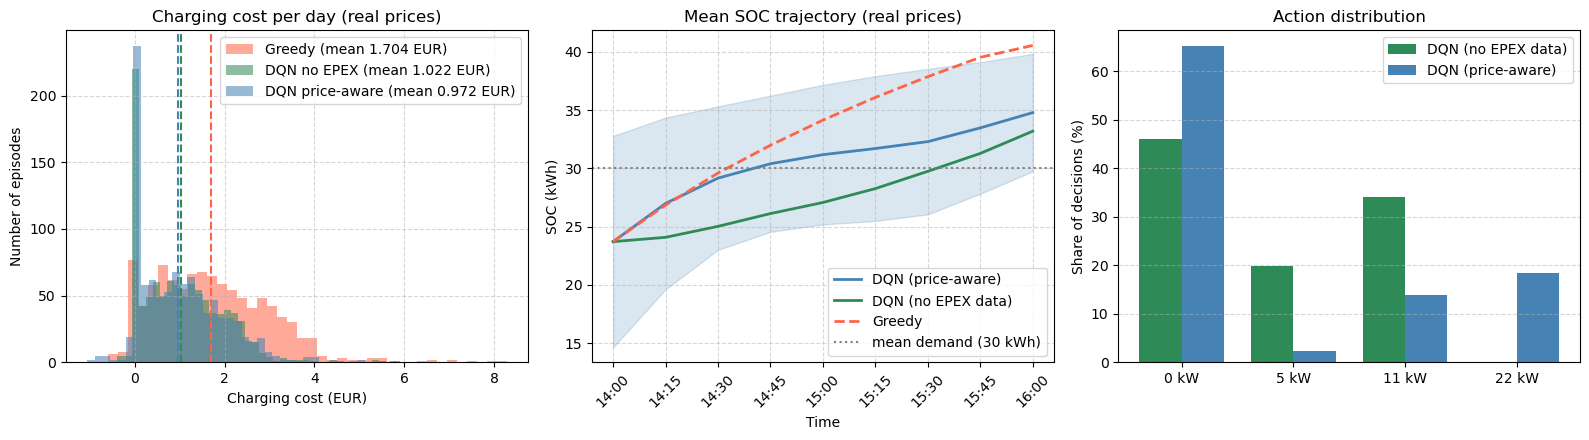

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) cost distribution of the three strategies (real prices)
ax[0].hist(grdB_c,  bins=40, alpha=0.55, color='tomato',    label=f'Greedy (mean {grdB_c.mean():.3f} EUR)')
ax[0].hist(dqnAe_c, bins=40, alpha=0.55, color='seagreen',  label=f'DQN no EPEX (mean {dqnAe_c.mean():.3f} EUR)')
ax[0].hist(dqnB_c,  bins=40, alpha=0.55, color='steelblue', label=f'DQN price-aware (mean {dqnB_c.mean():.3f} EUR)')
ax[0].axvline(grdB_c.mean(), color='tomato', ls='--')
ax[0].axvline(dqnAe_c.mean(), color='seagreen', ls='--')
ax[0].axvline(dqnB_c.mean(), color='steelblue', ls='--')
ax[0].set_title('Charging cost per day (real prices)')
ax[0].set_xlabel('Charging cost (EUR)'); ax[0].set_ylabel('Number of episodes')
ax[0].legend(); ax[0].grid(True, ls='--', alpha=0.5)

# (2) mean SOC trajectories of the three strategies
times = [14.0 + i*0.25 for i in range(9)]
ax[1].plot(times, dqnB_traj.mean(0), color='steelblue', lw=2, label='DQN (price-aware)')
ax[1].fill_between(times, dqnB_traj.mean(0)-dqnB_traj.std(0), dqnB_traj.mean(0)+dqnB_traj.std(0),
                   color='steelblue', alpha=0.2)
ax[1].plot(times, dqnAe_traj.mean(0), color='seagreen', lw=2, label='DQN (no EPEX data)')
ax[1].plot(times, grdB_traj.mean(0), color='tomato', lw=2, ls='--', label='Greedy')
ax[1].axhline(30, color='gray', ls=':', label='mean demand (30 kWh)')
ax[1].set_title('Mean SOC trajectory (real prices)')
ax[1].set_xlabel('Time'); ax[1].set_ylabel('SOC (kWh)')
ax[1].set_xticks(times); ax[1].set_xticklabels([f'{int(t)}:{int((t%1)*60):02d}' for t in times], rotation=45)
ax[1].legend(); ax[1].grid(True, ls='--', alpha=0.5)

# (3) action distribution of both DQN agents
labels = ['0 kW', '5 kW', '11 kW', '22 kW']
x = np.arange(len(labels)); w = 0.38
ax[2].bar(x - w/2, dqnAe_actions/dqnAe_actions.sum()*100, w, color='seagreen',  label='DQN (no EPEX data)')
ax[2].bar(x + w/2, dqnB_actions/dqnB_actions.sum()*100,  w, color='steelblue', label='DQN (price-aware)')
ax[2].set_xticks(x); ax[2].set_xticklabels(labels)
ax[2].set_title('Action distribution'); ax[2].set_ylabel('Share of decisions (%)')
ax[2].legend(); ax[2].grid(True, axis='y', ls='--', alpha=0.5)

plt.tight_layout(); plt.show()

### 7.1 Learning curves of both agents

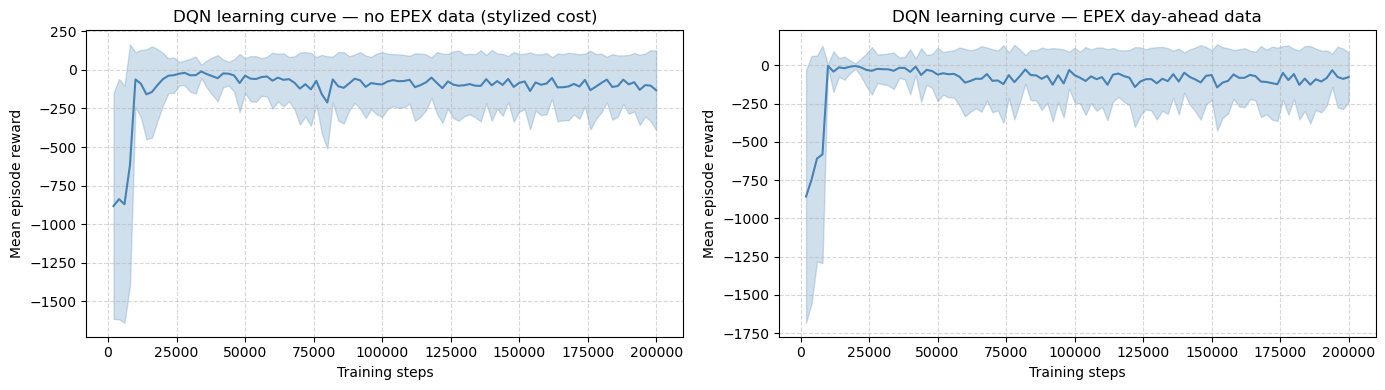

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for i, (path, title) in enumerate([('./logs/log_A/evaluations.npz', 'no EPEX data (stylized cost)'),
                                    ('./logs/log_B/evaluations.npz', 'EPEX day-ahead data')]):
    try:
        d = np.load(path)
        t = d['timesteps']; m = d['results'].mean(1); s = d['results'].std(1)
        ax[i].plot(t, m, color='steelblue'); ax[i].fill_between(t, m-s, m+s, color='steelblue', alpha=0.25)
        ax[i].set_title(f'DQN learning curve — {title}')
        ax[i].set_xlabel('Training steps'); ax[i].set_ylabel('Mean episode reward')
        ax[i].grid(True, ls='--', alpha=0.5)
    except FileNotFoundError:
        ax[i].text(0.5, 0.5, 'No logs found', ha='center', va='center')
plt.tight_layout(); plt.show()

### 7.2 Deeper diagnostics

Where do the savings of the EPEX-trained agent come from, and when is it better than the
fill-up rule? We look at the paired costs per episode and relate the saving to two episode
properties: the price spread within the charging window and the initial SOC.

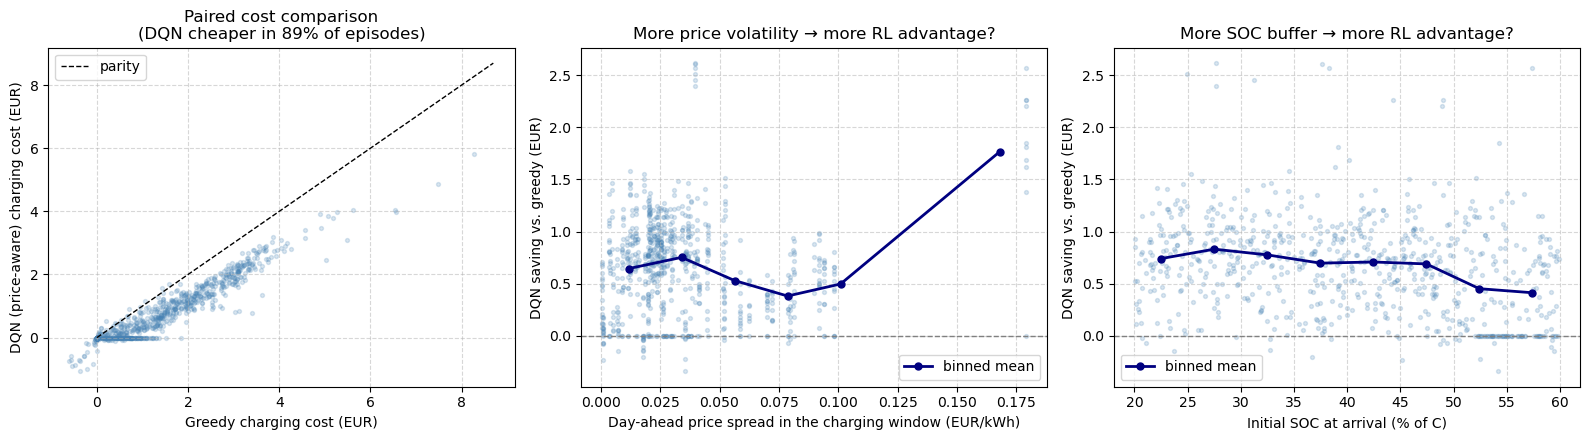

DQN cheaper: 676/759 episodes (89%)


In [19]:
# re-extract episode metadata via seeded reset (no stepping needed)
diag_env = TaxiChargingEnvEPEX(EPEX_WINDOWS)
meta_spread, meta_soc_frac = [], []
for sd in eval_seeds:
    diag_env.reset(seed=int(sd))
    meta_spread.append(float(diag_env.prices_da.max() - diag_env.prices_da.min()))
    meta_soc_frac.append(float(diag_env.initial_soc / diag_env.capacity * 100))
meta_spread   = np.array(meta_spread)
meta_soc_frac = np.array(meta_soc_frac)

ok         = dqnB_s & grdB_s
savings_ok = (grdB_c - dqnB_c)[ok]

def binned_mean(x, y, n_bins=8):
    """Mean of y in n equal-width x bins (at least 5 points per bin)."""
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    cx, cy = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x <= hi)
        if m.sum() >= 5:
            cx.append((lo + hi) / 2)
            cy.append(y[m].mean())
    return np.array(cx), np.array(cy)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) paired cost comparison
ax[0].scatter(grdB_c[ok], dqnB_c[ok], alpha=0.2, s=8, color='steelblue')
lim = max(grdB_c[ok].max(), dqnB_c[ok].max()) * 1.05
ax[0].plot([0, lim], [0, lim], 'k--', lw=1, label='parity')
pct = (dqnB_c[ok] < grdB_c[ok]).mean() * 100
ax[0].set_xlabel('Greedy charging cost (EUR)')
ax[0].set_ylabel('DQN (price-aware) charging cost (EUR)')
ax[0].set_title(f'Paired cost comparison\n(DQN cheaper in {pct:.0f}% of episodes)')
ax[0].legend()
ax[0].grid(True, ls='--', alpha=0.5)

# (2) saving vs. day-ahead price spread in the charging window
ax[1].scatter(meta_spread[ok], savings_ok, alpha=0.2, s=8, color='steelblue')
ax[1].axhline(0, color='gray', ls='--', lw=1)
cx, cy = binned_mean(meta_spread[ok], savings_ok)
ax[1].plot(cx, cy, color='navy', lw=2, marker='o', ms=5, label='binned mean')
ax[1].set_xlabel('Day-ahead price spread in the charging window (EUR/kWh)')
ax[1].set_ylabel('DQN saving vs. greedy (EUR)')
ax[1].set_title('More price volatility → more RL advantage?')
ax[1].legend()
ax[1].grid(True, ls='--', alpha=0.5)

# (3) saving vs. initial SOC
ax[2].scatter(meta_soc_frac[ok], savings_ok, alpha=0.2, s=8, color='steelblue')
ax[2].axhline(0, color='gray', ls='--', lw=1)
cx2, cy2 = binned_mean(meta_soc_frac[ok], savings_ok)
ax[2].plot(cx2, cy2, color='navy', lw=2, marker='o', ms=5, label='binned mean')
ax[2].set_xlabel('Initial SOC at arrival (% of C)')
ax[2].set_ylabel('DQN saving vs. greedy (EUR)')
ax[2].set_title('More SOC buffer → more RL advantage?')
ax[2].legend()
ax[2].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()
print(f'DQN cheaper: {(dqnB_c[ok] < grdB_c[ok]).sum()}/{ok.sum()} episodes ({pct:.0f}%)')

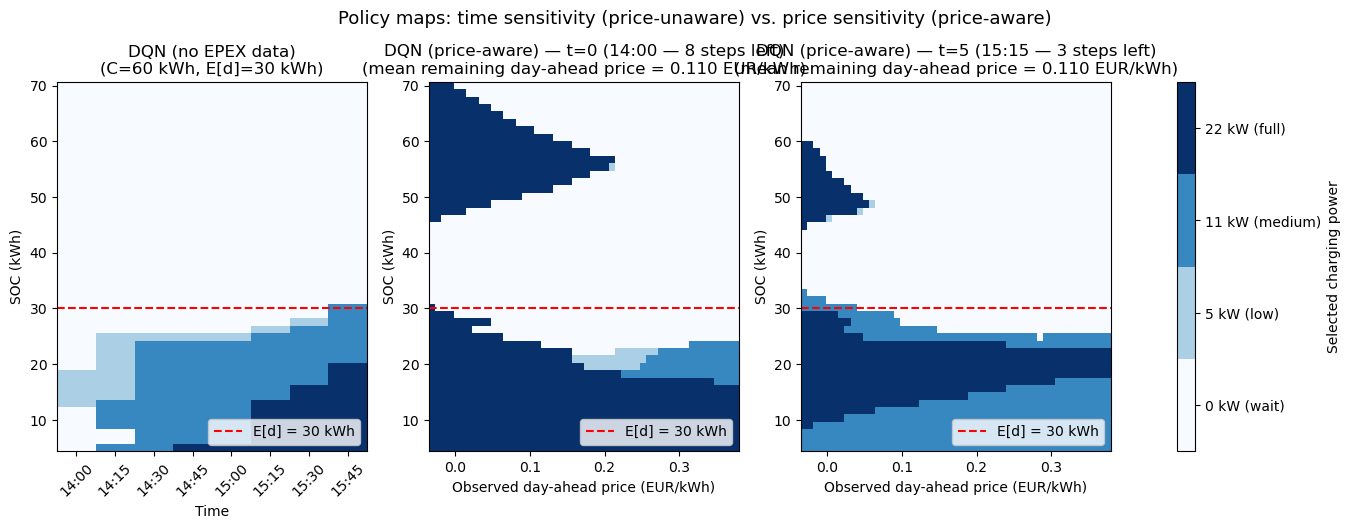

In [20]:
# Policy maps: the price-unaware agent depends only on (SOC, time); the price-aware
# agent additionally reacts to the observed day-ahead price.
soc_vals    = np.linspace(5, 70, 50)
t_vals      = np.arange(8)
price_vals  = np.linspace(EPEX_WINDOWS.min() - 0.005, EPEX_WINDOWS.max() + 0.005, 50)
C_fix, d_fix = 60.0, 30.0
med_p       = float(np.median(EPEX_WINDOWS))
time_labels = ['14:00', '14:15', '14:30', '14:45', '15:00', '15:15', '15:30', '15:45']

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
cmap_pol = plt.get_cmap('Blues', 4)

# (1) DQN without EPEX data: power vs. (SOC, time)
grid = np.zeros((len(soc_vals), len(t_vals)), dtype=int)
for i, soc in enumerate(soc_vals):
    for j, t in enumerate(t_vals):
        obs = np.array([soc, float(t), C_fix], dtype=np.float32)
        grid[i, j] = int(model_A.predict(obs, deterministic=True)[0])
im = axes[0].pcolormesh(t_vals, soc_vals, grid, cmap=cmap_pol, vmin=-0.5, vmax=3.5)
axes[0].axhline(d_fix, color='red', ls='--', lw=1.5, label=f'E[d] = {int(d_fix)} kWh')
axes[0].set_xticks(t_vals); axes[0].set_xticklabels(time_labels, rotation=45)
axes[0].set_xlabel('Time'); axes[0].set_ylabel('SOC (kWh)')
axes[0].set_title(f'DQN (no EPEX data)\n(C={int(C_fix)} kWh, E[d]={int(d_fix)} kWh)')
axes[0].legend(loc='lower right')

# (2)+(3) price-aware DQN: power vs. (SOC, day-ahead price) early and late in the window
for col, (t_step, t_label) in enumerate([(0, 't=0 (14:00 — 8 steps left)'),
                                          (5, 't=5 (15:15 — 3 steps left)')], start=1):
    grid = np.zeros((len(soc_vals), len(price_vals)), dtype=int)
    for i, soc in enumerate(soc_vals):
        for j, price in enumerate(price_vals):
            obs = np.array([soc, float(t_step), C_fix, price, med_p], dtype=np.float32)
            grid[i, j] = int(model_B.predict(obs, deterministic=True)[0])
    im = axes[col].pcolormesh(price_vals, soc_vals, grid, cmap=cmap_pol, vmin=-0.5, vmax=3.5)
    axes[col].axhline(d_fix, color='red', ls='--', lw=1.5, label=f'E[d] = {int(d_fix)} kWh')
    axes[col].set_xlabel('Observed day-ahead price (EUR/kWh)')
    axes[col].set_ylabel('SOC (kWh)')
    axes[col].set_title(f'DQN (price-aware) — {t_label}\n'
                         f'(mean remaining day-ahead price = {med_p:.3f} EUR/kWh)')
    axes[col].legend(loc='lower right')

cbar = plt.colorbar(im, ax=axes.tolist(), ticks=[0, 1, 2, 3])
cbar.set_ticklabels(['0 kW (wait)', '5 kW (low)', '11 kW (medium)', '22 kW (full)'])
cbar.set_label('Selected charging power')
plt.suptitle('Policy maps: time sensitivity (price-unaware) vs. price sensitivity (price-aware)',
             fontsize=13, y=1.03)
plt.show()

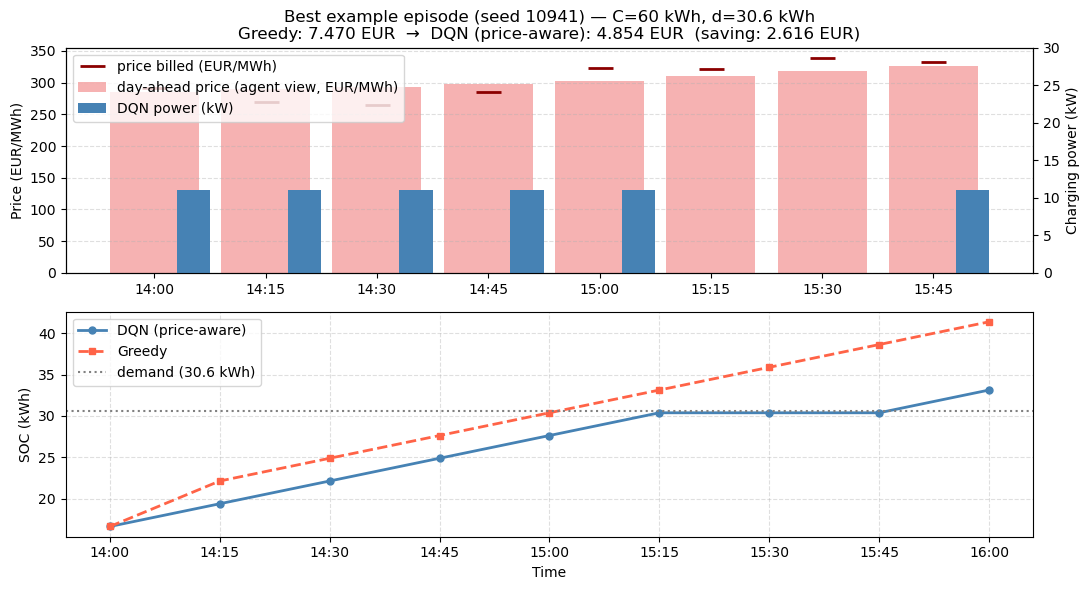

In [21]:
# best episode: largest absolute saving of the price-aware DQN (both strategies successful)
ok_ep       = dqnB_s & grdB_s
savings_all = np.where(ok_ep, grdB_c - dqnB_c, -np.inf)
best_idx    = int(np.argmax(savings_all))
best_seed   = int(eval_seeds[best_idx])

# DQN run with detailed tracking
ep_env = TaxiChargingEnvEPEX(EPEX_WINDOWS)
obs, _ = ep_env.reset(seed=best_seed)
prices_da_ep   = ep_env.prices_da.copy()    # what the agent sees
prices_paid_ep = ep_env.prices_real.copy()  # what is billed
cap_ep, demand_ep = ep_env.capacity, ep_env.demand
soc_dqn, powers_ep, costs_ep = [ep_env.soc], [], []
done = False
while not done:
    action, _ = model_B.predict(obs, deterministic=True)
    obs, _, done, _, info = ep_env.step(int(action))
    powers_ep.append(info['power'])
    costs_ep.append(info['charging_cost'])
    soc_dqn.append(ep_env.soc)

# greedy run on the identical seed
grd_ep_env = TaxiChargingEnvEPEX(EPEX_WINDOWS)
_, cost_grd_ep, _, soc_grd = greedy_episode(grd_ep_env, seed=best_seed)

step_ticks = ['14:00','14:15','14:30','14:45','15:00','15:15','15:30','15:45']
full_ticks  = step_ticks + ['16:00']
power_color = {0: 'lightgray', 5: 'skyblue', 11: 'steelblue', 22: 'navy'}

fig, ax = plt.subplots(2, 1, figsize=(11, 6))

# top: day-ahead price (agent view, bars) + billed price (markers) + DQN charging power
ax[0].bar(range(8), np.array(prices_da_ep) * 1000, color='lightcoral', alpha=0.6,
          label='day-ahead price (agent view, EUR/MWh)')
ax[0].plot(range(8), np.array(prices_paid_ep) * 1000, color='darkred', ls='none',
           marker='_', ms=18, mew=2, label='price billed (EUR/MWh)')
ax0r = ax[0].twinx()
ax0r.bar([x + 0.35 for x in range(8)], powers_ep, width=0.3,
         color=[power_color[p] for p in powers_ep], label='DQN power (kW)')
ax0r.set_ylabel('Charging power (kW)')
ax0r.set_ylim(0, 30)
ax[0].set_ylabel('Price (EUR/MWh)')
ax[0].set_xticks(range(8))
ax[0].set_xticklabels(step_ticks)
total_dqn = sum(costs_ep)
ax[0].set_title(f'Best example episode (seed {best_seed}) — '
                f'C={int(cap_ep)} kWh, d={demand_ep:.1f} kWh\n'
                f'Greedy: {cost_grd_ep:.3f} EUR  →  DQN (price-aware): {total_dqn:.3f} EUR  '
                f'(saving: {cost_grd_ep - total_dqn:.3f} EUR)')
l0, lb0   = ax[0].get_legend_handles_labels()
l0r, lb0r = ax0r.get_legend_handles_labels()
ax[0].legend(l0 + l0r, lb0 + lb0r, loc='upper left')
ax[0].grid(True, axis='y', ls='--', alpha=0.4)

# bottom: SOC trajectory DQN vs. greedy
ax[1].plot(range(9), soc_dqn, color='steelblue', lw=2, marker='o', ms=5, label='DQN (price-aware)')
ax[1].plot(range(9), soc_grd, color='tomato',    lw=2, ls='--', marker='s', ms=4, label='Greedy')
ax[1].axhline(demand_ep, color='gray', ls=':', lw=1.5, label=f'demand ({demand_ep:.1f} kWh)')
ax[1].set_xticks(range(9))
ax[1].set_xticklabels(full_ticks)
ax[1].set_xlabel('Time')
ax[1].set_ylabel('SOC (kWh)')
ax[1].legend()
ax[1].grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## 8. Interpretation and implications for the fleet operator

**The central result of the three-way comparison** (the demand $d$ is in all cases known only at
departure; only the price-aware DQN observes the day-ahead prices, and nobody observes the
realized procurement price):

- **Stylized cost setting:** Under demand uncertainty the service-level heuristic (charge to
  $\mu + 2\sigma$) is very hard to beat: **98.9%** success, close to the oracle optimum. The
  DQN charges only toward the mean demand, under-insures, and reaches **70.1%** success —
  without systematic price variation RL adds no value and mis-prices the demand tail.

- **Real EPEX prices — the day-ahead forecast has real value:** The price-aware DQN saves
  **+0.66 €/day (≈ 43%)** against the price-blind heuristic on episodes where both cover the
  demand and is cheaper in **89%** of them. Crucially, it now beats the price-unaware DQN on
  *both* axes (success **75.9%** vs. 70.1%, cost 0.97 vs. 1.02 €/day) — the difference is
  genuine price knowledge, not just risk appetite. The policy maps show the intended pattern:
  above a SOC threshold near the expected demand, the agent charges at full power when the
  observed day-ahead price is low and waits when it is high, while at low SOC the approaching
  deadline overrides the price. The unobserved procurement deviation (± ≈ 15 €/MWh) does not
  destroy this edge: the deviation is zero-mean, so planning on the market's expectation still
  ranks the quarter-hours correctly on average.

- **The price of the savings — still under-insurance:** At **75.9%** success vs. greedy's
  98.9%, a substantial part of both DQNs' savings remains forgone safety margin rather than
  timing. (The price-aware agent's raw mean cost of 0.97 €/day even sits at the oracle's level
  — but that figure is flattered by failed episodes in which it simply bought too little
  energy; the paired saving on jointly successful episodes is the honest metric.) The oracle —
  100% success at ≈ 0.97 €/day — knows the realized demand and the realized prices; the
  heuristic pays ≈ 0.73 €/day more as an insurance premium for near-certain success.

**When is smart charging worthwhile?** Cost figures must be read together with the success
rate: a strategy that saves two thirds of a euro per day but fails a quarter of the days is not
operationally viable. With price information now in the state, the remaining weakness is purely
the **demand hedge** — so a learned policy belongs behind a **safety layer** (e.g., a hard
minimum-SOC target in the final steps, or a higher/asymmetric shortage penalty during
training), which would sacrifice little of the timing-based savings while restoring
reliability. The stronger the price fluctuations within the window, the larger the savings
potential of price-aware charging (section 7.2).

**Private vs. public charging infrastructure.** Since home charging (14:00–16:00) is a
plannable, controllable charging phase, an operator with **its own charging infrastructure and a
dynamic tariff** can deliberately exploit the cheap day-ahead windows — an advantage that public
charging stations with fixed, usually higher tariffs do not offer. Smart charging is therefore
attractive above all in combination with **a private wallbox plus a dynamic electricity contract
or own generation**.